In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("TelcoChurn.xlsx")

print("Jumlah baris   :", df.shape[0])
print("Jumlah kolom   :", df.shape[1])

df.head()

Jumlah baris   : 7043
Jumlah kolom   : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Series([], dtype: int64)


In [5]:
print("Jumlah duplicate:", df.duplicated().sum())

Jumlah duplicate: 0


In [6]:
print("Duplicate customerID:", df["customerID"].duplicated().sum())

Duplicate customerID: 0


In [7]:
print(df["Churn"].value_counts())

print("\nPersentase:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


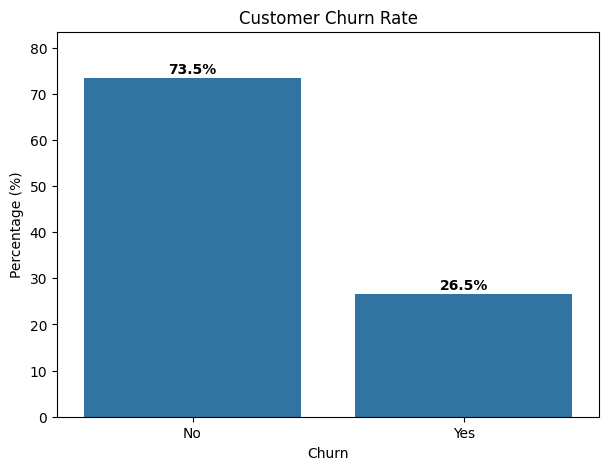

In [8]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=churn_percentage.index,
    y=churn_percentage.values
)

plt.title("Customer Churn Rate")
plt.xlabel("Churn")
plt.ylabel("Percentage (%)")

for i, value in enumerate(churn_percentage.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, max(churn_percentage.values) + 10)

plt.show()

In [9]:
# "Pelanggan dengan kontrak apa yang paling banyak churn?"
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


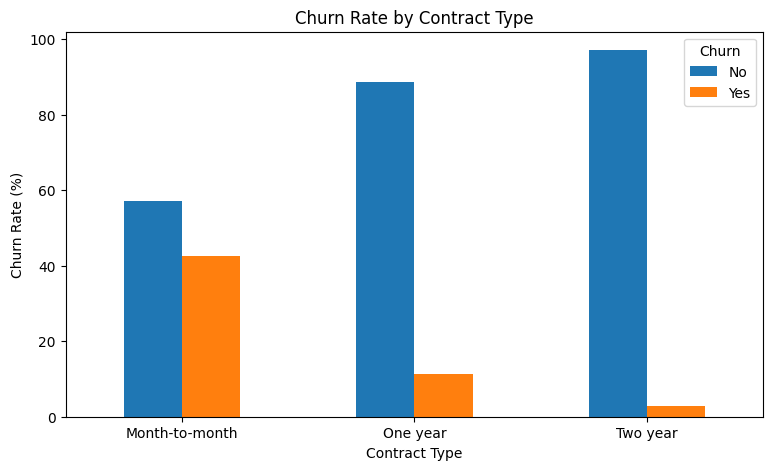

In [10]:
contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

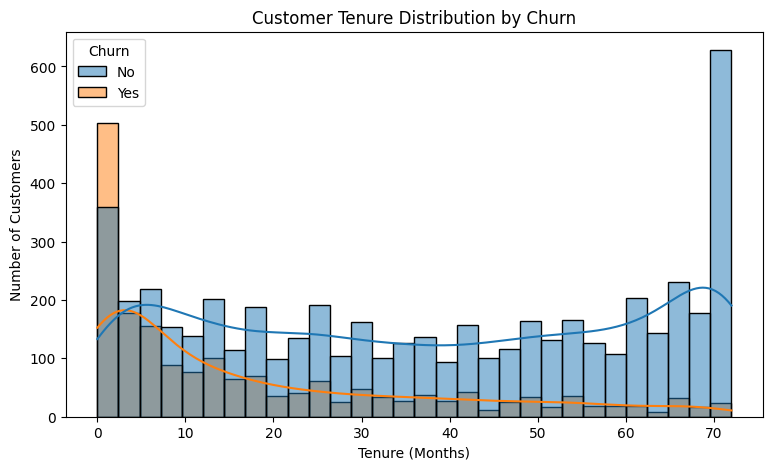

In [11]:
# Apakah customer dengan masa berlangganan pendek lebih rentan churn?
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

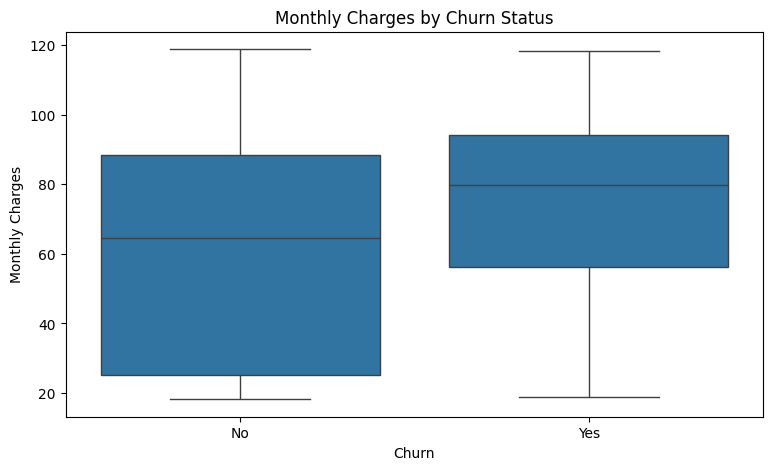

In [12]:
#apakah pelanggan yang membayar lebih mahal cenderung churn.
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [13]:
df["TotalCharges"].value_counts().head(20)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
19.45     6
20.3      5
20.45     5
19.85     4
69.9      4
20.4      4
70.6      4
19.2      4
69.65     4
44        4
Name: count, dtype: int64

In [14]:
print(
    df.loc[
        pd.to_numeric(df["TotalCharges"], errors="coerce").isna(),
        ["customerID", "tenure", "TotalCharges"]
    ]
)

      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


In [15]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [16]:
print(df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

float64
Missing TotalCharges: 11


In [17]:
df[df["TotalCharges"].isna()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [18]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [19]:
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Missing TotalCharges: 0


In [20]:
df.loc[
    df["tenure"] == 0,
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,0.0,No
753,0,20.25,0.0,No
936,0,80.85,0.0,No
1082,0,25.75,0.0,No
1340,0,56.05,0.0,No
3331,0,19.85,0.0,No
3826,0,25.35,0.0,No
4380,0,20.00,0.0,No
5218,0,19.70,0.0,No
6670,0,73.35,0.0,No


In [21]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerID:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customerID: 0


In [22]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].unique())
    


===== customerID =====
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

===== gender =====
['Female' 'Male']

===== Partner =====
['Yes' 'No']

===== Dependents =====
['No' 'Yes']

===== PhoneService =====
['No' 'Yes']

===== MultipleLines =====
['No phone service' 'No' 'Yes']

===== InternetService =====
['DSL' 'Fiber optic' 'No']

===== OnlineSecurity =====
['No' 'Yes' 'No internet service']

===== OnlineBackup =====
['Yes' 'No' 'No internet service']

===== DeviceProtection =====
['No' 'Yes' 'No internet service']

===== TechSupport =====
['No' 'Yes' 'No internet service']

===== StreamingTV =====
['No' 'Yes' 'No internet service']

===== StreamingMovies =====
['No' 'Yes' 'No internet service']

===== Contract =====
['Month-to-month' 'One year' 'Two year']

===== PaperlessBilling =====
['Yes' 'No']

===== PaymentMethod =====
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

===== Churn =====
['No' 'Yes']

In [23]:
# ubah lama berlangganan menjadi kelompok (tenure group)
def tenure_group(tenure):
    if tenure <= 12:
        return "New"
    elif tenure <= 24:
        return "Early"
    elif tenure <= 48:
        return "Mid"
    else:
        return "Loyal"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

In [24]:
print(df["TenureGroup"].value_counts())

TenureGroup
Loyal    2239
New      2186
Mid      1594
Early    1024
Name: count, dtype: int64


In [25]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [26]:
df["TotalServices"] = (
    df[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

In [27]:
df[["customerID", "TotalServices", "Churn"]].head(10)

,customerID,TotalServices,Churn
0,7590-VHVEG,1,No
1,5575-GNVDE,3,No
2,3668-QPYBK,3,Yes
3,7795-CFOCW,3,No
4,9237-HQITU,1,Yes
5,9305-CDSKC,5,Yes
6,1452-KIOVK,4,No
7,6713-OKOMC,1,No
8,7892-POOKP,6,Yes
9,6388-TABGU,3,No


In [28]:
df["AverageMonthlyCharges"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

In [29]:
df["IsLongTermContract"] = (
    df["Contract"] != "Month-to-month"
).astype(int)

In [30]:
df[
    [
        "tenure",
        "TenureGroup",
        "TotalServices",
        "MonthlyCharges",
        "TotalCharges",
        "AverageMonthlyCharges",
        "Contract",
        "IsLongTermContract",
        "Churn"
    ]
].head(10)

,tenure,TenureGroup,TotalServices,MonthlyCharges,TotalCharges,AverageMonthlyCharges,Contract,IsLongTermContract,Churn
0,1,New,1,29.85,29.85,29.850000,Month-to-month,0,No
1,34,Mid,3,56.95,1889.50,55.573529,One year,1,No
2,2,New,3,53.85,108.15,54.075000,Month-to-month,0,Yes
3,45,Mid,3,42.30,1840.75,40.905556,One year,1,No
4,2,New,1,70.70,151.65,75.825000,Month-to-month,0,Yes
5,8,New,5,99.65,820.50,102.562500,Month-to-month,0,Yes
6,22,Early,4,89.10,1949.40,88.609091,Month-to-month,0,No
7,10,New,1,29.75,301.90,30.190000,Month-to-month,0,No
8,28,Mid,6,104.80,3046.05,108.787500,Month-to-month,0,Yes
9,62,Loyal,3,56.15,3487.95,56.257258,One year,1,No


In [31]:
print(df.shape)

(7043, 25)


In [32]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

Churn               No        Yes
TenureGroup                      
Early        71.289062  28.710938
Loyal        90.486824   9.513176
Mid          79.611041  20.388959
New          52.561757  47.438243


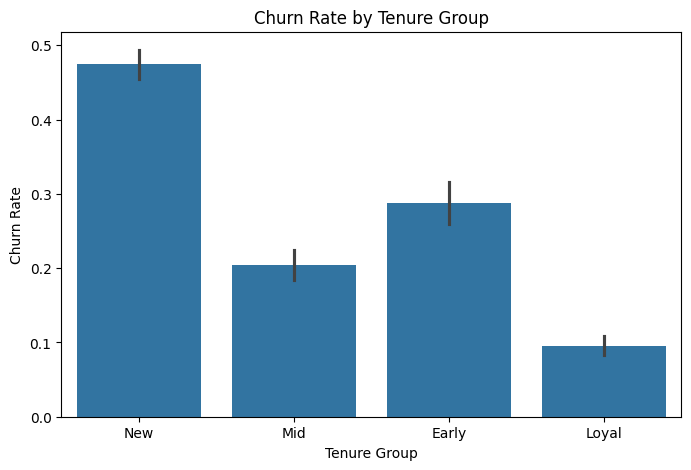

In [33]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x="TenureGroup",
    y=df["Churn"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")

plt.show()

In [34]:
tenure_rate = (
    df.groupby("TenureGroup")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(tenure_rate)

TenureGroup
New      47.438243
Early    28.710938
Mid      20.388959
Loyal     9.513176
Name: Churn, dtype: float64


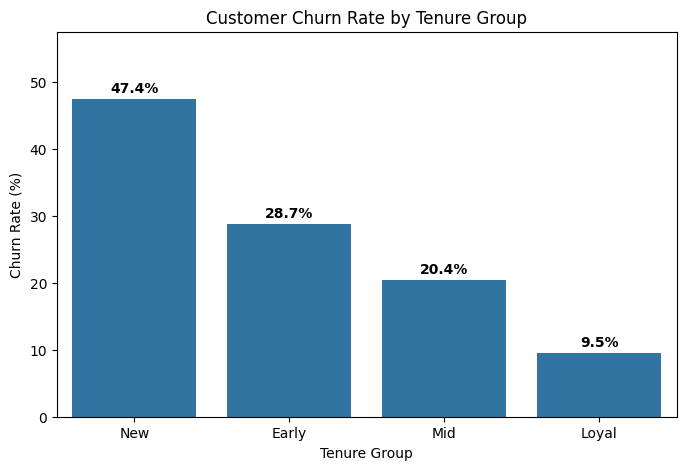

In [35]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=tenure_rate.index,
    y=tenure_rate.values
)

plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(tenure_rate.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, max(tenure_rate.values) + 10)

plt.show()

In [36]:
contract_rate = (
    df.groupby("IsLongTermContract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

contract_rate.index = [
    "Month-to-month",
    "Long-term"
]

print(contract_rate)

Month-to-month    42.709677
Long-term          6.755051
Name: Churn, dtype: float64


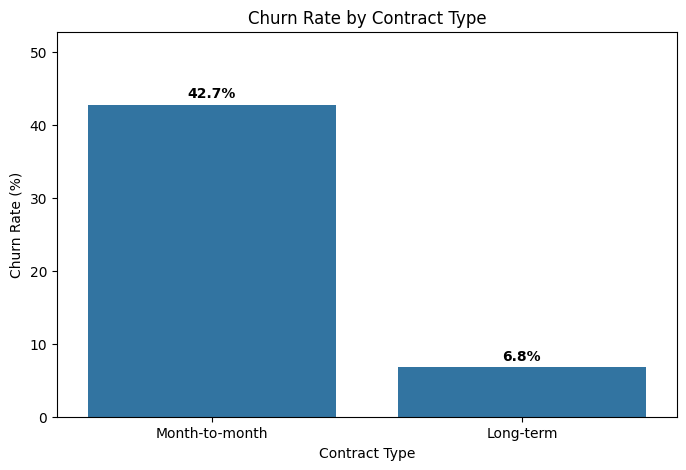

In [37]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=contract_rate.index,
    y=contract_rate.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(contract_rate.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, max(contract_rate.values) + 10)

plt.show()

In [38]:
service_rate = (
    df.groupby("TotalServices")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(service_rate)

TotalServices
0    43.750000
1    21.105232
2    32.828283
3    36.476684
4    31.344902
5    25.550661
6    22.485207
7    12.405063
8     5.288462
Name: Churn, dtype: float64


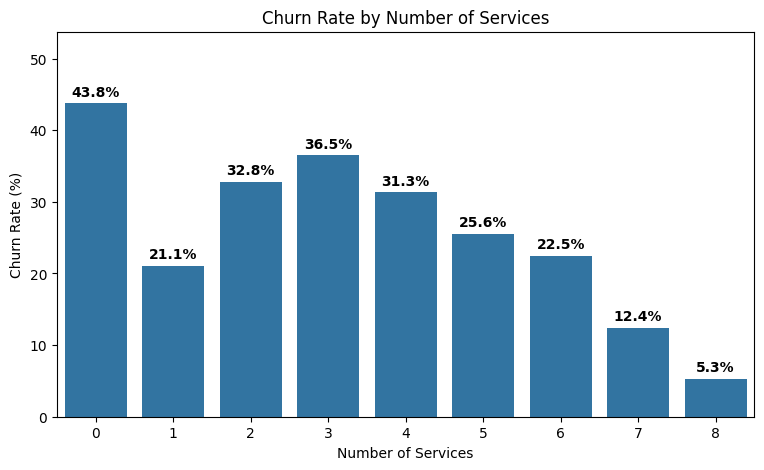

In [39]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=service_rate.index,
    y=service_rate.values
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(service_rate.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, max(service_rate.values) + 10)

plt.show()

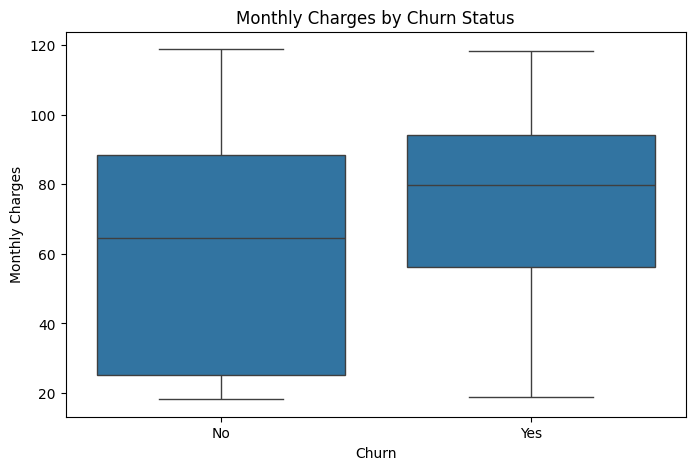

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [41]:
payment_rate = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(payment_rate)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


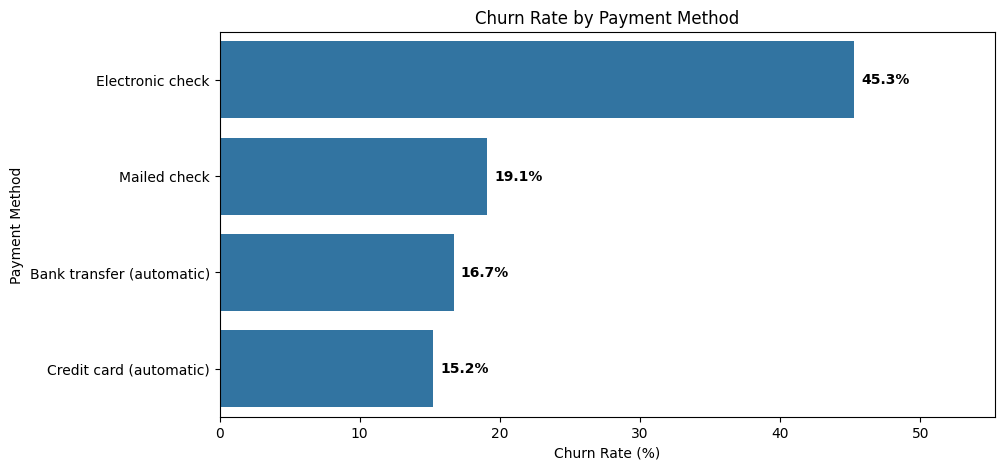

In [42]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=payment_rate.values,
    y=payment_rate.index
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

for i, value in enumerate(payment_rate.values):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center",
        fontweight="bold"
    )

plt.xlim(0, max(payment_rate.values) + 10)

plt.show()

In [43]:
service_summary = df.groupby("TotalServices").agg(
    Customers=("customerID", "count"),
    ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
)

print(service_summary)

               Customers  ChurnRate
TotalServices                      
0                     80  43.750000
1                   1701  21.105232
2                   1188  32.828283
3                    965  36.476684
4                    922  31.344902
5                    908  25.550661
6                    676  22.485207
7                    395  12.405063
8                    208   5.288462


In [44]:
payment_summary = df.groupby("PaymentMethod").agg(
    Customers=("customerID", "count"),
    ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
).sort_values("ChurnRate", ascending=False)

print(payment_summary)

                           Customers  ChurnRate
PaymentMethod                                  
Electronic check                2365  45.285412
Mailed check                    1612  19.106700
Bank transfer (automatic)       1544  16.709845
Credit card (automatic)         1522  15.243101


In [45]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Churn,,,,
No,5174,61.265124,64.425,31.092648
Yes,1869,74.441332,79.650,24.666053


In [46]:
df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Churn,,,,
No,5174,37.569965,38.0,24.113777
Yes,1869,17.979133,10.0,19.531123


In [47]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [48]:
X = X.drop(columns=["customerID"])

In [49]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numeric:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'AverageMonthlyCharges', 'IsLongTermContract']

Categorical:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 23)
X_test : (1409, 23)
y_train: (5634,)
y_test : (1409,)


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [52]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [54]:
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [55]:
logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'TotalServices',
                                                   'AverageMonthlyCharges',
                                                   'IsLongTermContract']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [56]:
y_pred = logreg_pipeline.predict(X_test)
y_prob = logreg_pipeline.predict_proba(X_test)[:, 1]

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Logistic Regression Baseline ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

=== Logistic Regression Baseline ===
Accuracy : 0.7991
Precision: 0.6532
Recall   : 0.5187
F1-score : 0.5782
ROC-AUC  : 0.8423


In [58]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



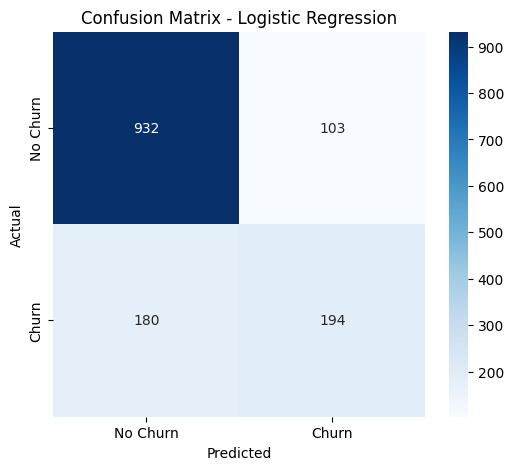

In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

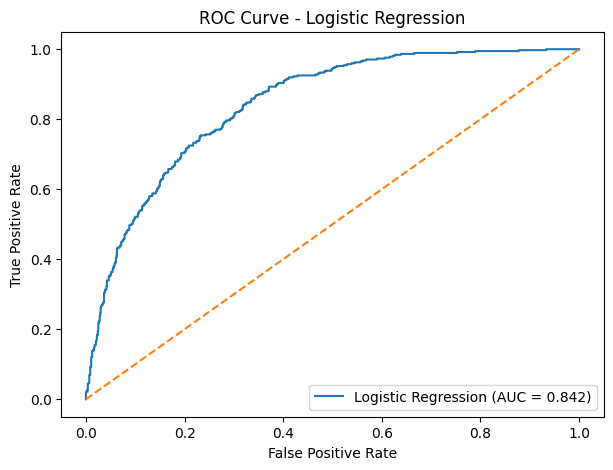

In [60]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [61]:
## LANJUT RANDOM FOREST

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [63]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'TotalServices',
                                                   'AverageMonthlyCharges',
                                                   'IsLongTermContract']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [64]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [65]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== Random Forest Baseline ===")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

=== Random Forest Baseline ===
Accuracy : 0.7828
Precision: 0.6133
Recall   : 0.4920
F1-score : 0.5460
ROC-AUC  : 0.8228


In [66]:
from xgboost import XGBClassifier

In [67]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

In [68]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'TotalServices',
                                                   'AverageMonthlyCharges',
                                                   'IsLongTermContract']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'Partne...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [69]:
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [70]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=== XGBoost Baseline ===")
print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1-score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")

=== XGBoost Baseline ===
Accuracy : 0.7942
Precision: 0.6391
Recall   : 0.5160
F1-score : 0.5710
ROC-AUC  : 0.8363


In [71]:
#deploy model LR
import joblib

joblib.dump(
    logreg_pipeline,
    "churn_model.pkl"
)

['churn_model.pkl']

In [73]:
print(X_train.dtypes)

gender                    object
SeniorCitizen              int64
Partner                   object
Dependents                object
tenure                     int64
PhoneService              object
MultipleLines             object
InternetService           object
OnlineSecurity            object
OnlineBackup              object
DeviceProtection          object
TechSupport               object
StreamingTV               object
StreamingMovies           object
Contract                  object
PaperlessBilling          object
PaymentMethod             object
MonthlyCharges           float64
TotalCharges             float64
TenureGroup               object
TotalServices              int64
AverageMonthlyCharges    float64
IsLongTermContract         int64
dtype: object


In [74]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [75]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [77]:
lr_smote_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "smote",
            SMOTE(
                random_state=42
            )
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [78]:
lr_smote_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'TotalServices',
                                                   'AverageMonthlyCharges',
                                                   'IsLongTermContract']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [79]:
y_pred_smote = lr_smote_pipeline.predict(
    X_test
)

y_prob_smote = (
    lr_smote_pipeline
    .predict_proba(X_test)[:, 1]
)

In [80]:
print("=== Logistic Regression + SMOTE ===")

print(
    f"Accuracy : "
    f"{accuracy_score(y_test, y_pred_smote):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, y_pred_smote):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test, y_pred_smote):.4f}"
)

print(
    f"F1-score : "
    f"{f1_score(y_test, y_pred_smote):.4f}"
)

print(
    f"ROC-AUC  : "
    f"{roc_auc_score(y_test, y_prob_smote):.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_smote
    )
)

=== Logistic Regression + SMOTE ===
Accuracy : 0.7381
Precision: 0.5043
Recall   : 0.7914
F1-score : 0.6160
ROC-AUC  : 0.8398

Confusion Matrix:
[[744 291]
 [ 78 296]]


In [81]:
import joblib

joblib.dump(
    lr_smote_pipeline,
    "churn_smote_model.pkl"
)

['churn_smote_model.pkl']